Librerías y Funciones propias:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt

Simulation:

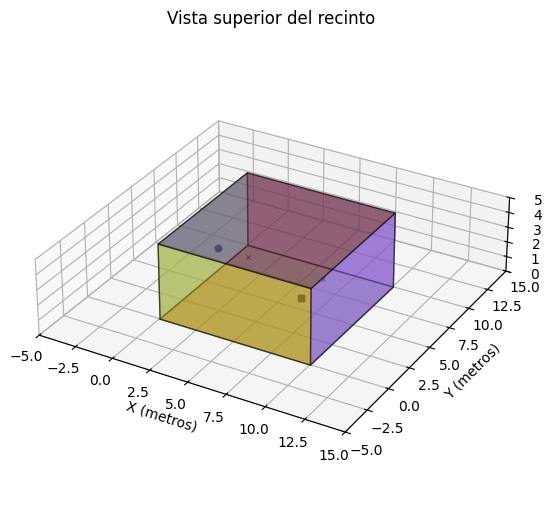

In [2]:
# Sampling frequency
fs = 48000 

# Room dimensions (width*length)
roomDimensions = [10, 10, 5]

# Create a room
room = pra.ShoeBox(roomDimensions, fs=fs, max_order=0)

# Sound source position (x,y,z)
sourcePosition = [1, 5, 2.5]
room.add_source(sourcePosition)

# Controller speaker position (x,y,z)
controllerSpeakerPosition = [8, 2.5, 2.5]
room.add_source(controllerSpeakerPosition)

# Reference microphone
referenceMicPosition = [3, 5, 2.5]

# Error microphone
errorMicPosition = [8, 5, 2.5]

# Add microphones to the room
room.add_microphone(referenceMicPosition, fs=fs)
room.add_microphone(errorMicPosition, fs=fs)

fig, ax = room.plot()
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
ax.set_aspect('equal')
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()


Obtain RIRs:

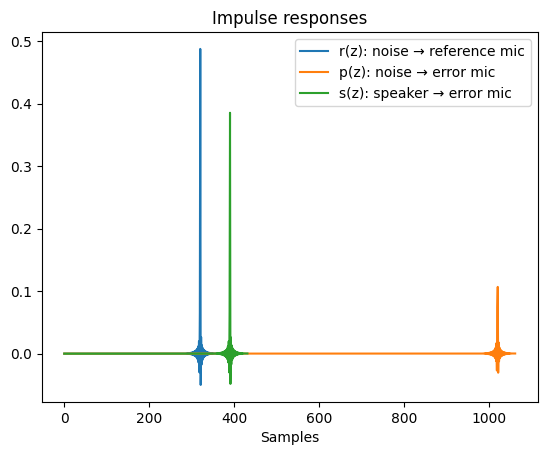

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
362
1062
432


In [3]:
room.compute_rir()
rir_r = room.rir[0][0]   # noise → reference mic
rir_p = room.rir[1][0]   # noise → error mic
rir_s = room.rir[1][1]   # speaker → error mic

plt.figure()
plt.plot(rir_r, label='r(z): noise → reference mic')
plt.plot(rir_p, label='p(z): noise → error mic')
plt.plot(rir_s, label='s(z): speaker → error mic')
plt.legend()
plt.title("Impulse responses")
plt.xlabel("Samples")
plt.show()

delay_r = np.argmax(np.abs(rir_r))
delay_p = np.argmax(np.abs(rir_p))
delay_s = np.argmax(np.abs(rir_s))

print("Delay R:", delay_r * 1000 / fs, "ms")
print("Delay P:", delay_p * 1000 / fs, "ms")
print("Delay S:", delay_s * 1000 / fs, "ms")

print("In order to comply with causality, computational time must be smaller than:", (delay_p * 1000 / fs) - (delay_r * 1000 / fs) - (delay_s * 1000 / fs), "ms")

print(len(rir_r))
print(len(rir_p))
print(len(rir_s))


FxLMS por bloques

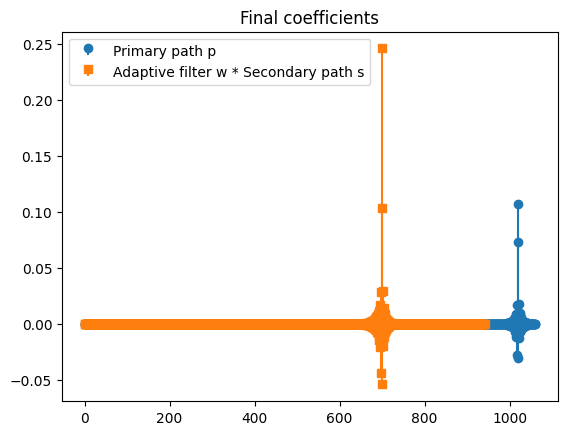

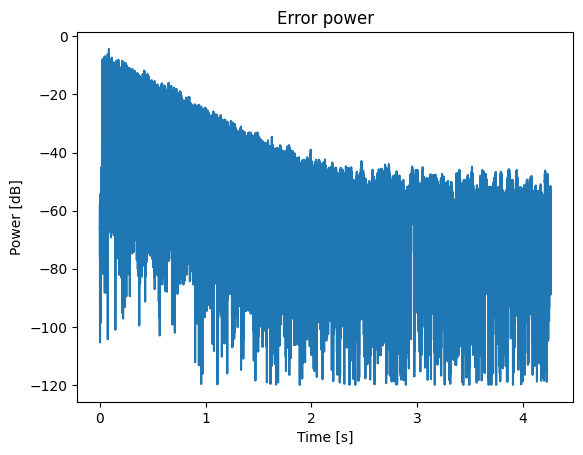

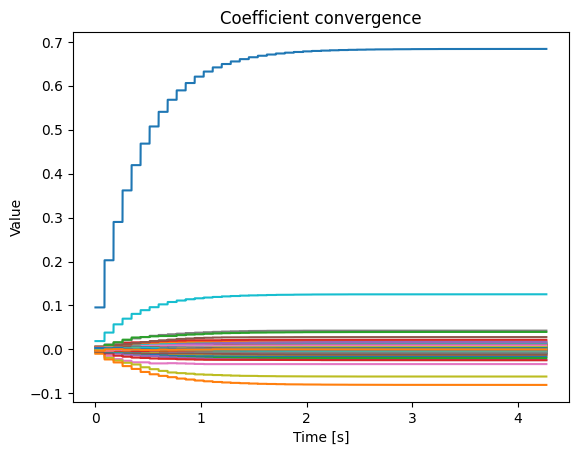

In [4]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 50
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 5
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = rir_s
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)
w_hist = np.zeros((N, M_w))

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z) + secondary path S(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fyBlockOutput)

    # Error signal
    e = pBlockOutput - fyBlockOutput

    # Filtered X
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    # LMS algorithm
    w = adapt(fxBlockOutput, e, M_w, blocklength, w, mu)

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e
    w_hist[k * blocklength:(k+1) * blocklength, :] = w


plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(M_w):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()
